# Study 1: Monthly DNA Rate Forecasting — Complete Pipeline
## NHS GP Appointment Data (Oct 2023 – Mar 2026)

**Dataset:** NHS England GP Appointment Publication Summary, March 2026  
**Tables used:** Table 1a (GP practice systems), 1b (PCN systems), 1c (combined)  
**Target variable:** Monthly GP DNA rate (%)  
**Models:** SARIMA | Prophet | Random Forest | XGBoost | MLP  
**Pipeline stages:** Ingestion → Cleaning → EDA → Feature Engineering → Feature Selection → Modelling → Evaluation

---

In [1]:
# ─── CELL 1: Imports & Setup ───────────────────────────────────────────────
import warnings, os, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from xgboost import XGBRegressor

# Colour palette
PALETTE = {
    "SARIMA":   "#1B4F8A",
    "Prophet":  "#E05C2E",
    "RF":       "#2E8B57",
    "XGBoost":  "#8B4EA6",
    "MLP":      "#C9840A",
    "actual":   "#1A1A2E",
}
MODEL_COLORS = [PALETTE[m] for m in ["SARIMA","Prophet","RF","XGBoost","MLP"]]

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35, "figure.dpi": 110,
})
print("Imports complete ✓")

Imports complete ✓


## Stage 1 — Data Ingestion

In [3]:
# ─── CELL 2: Data Ingestion ────────────────────────────────────────────────
# Adjust paths as needed
PATH_1A = "/content/GP_Appointment_Publication_Summary_March_2026(Table 1a).csv"
PATH_1B = "/content/GP_Appointment_Publication_Summary_March_2026(Table 1b).csv"
PATH_1C = "/content/GP_Appointment_Publication_Summary_March_2026(Table 1c).csv"

def parse_table(path):
    return pd.read_csv(path, encoding="latin1", header=None)

t1a = parse_table(PATH_1A)
t1b = parse_table(PATH_1B)
t1c = parse_table(PATH_1C)

def extract_series(df, row_idx, col_start=2, col_end=32):
    vals = df.iloc[row_idx, col_start:col_end].tolist()
    cleaned = []
    for v in vals:
        if pd.isna(v) or str(v).strip() in ["", ".z", "—"]:
            cleaned.append(np.nan)
        else:
            s = str(v).strip().replace(",", "").replace("%", "")
            try:   cleaned.append(float(s))
            except: cleaned.append(np.nan)
    return cleaned

months_raw = t1a.iloc[9, 2:32].tolist()
months = pd.to_datetime([m for m in months_raw if pd.notna(m)], format="%b-%y")
n = len(months)

# Extract key series from 1a
working_days   = extract_series(t1a, 18)[:n]
total_appts    = extract_series(t1a, 20)[:n]
dna_pct        = extract_series(t1a, 86)[:n]    # TARGET
attended_pct   = extract_series(t1a, 85)[:n]
f2f_pct        = extract_series(t1a, 95)[:n]
phone_pct      = extract_series(t1a, 97)[:n]
video_pct      = extract_series(t1a, 98)[:n]
same_day_pct   = extract_series(t1a, 101)[:n]
d28p_pct       = extract_series(t1a, 107)[:n]
gp_pct         = extract_series(t1a, 89)[:n]
nurse_pct      = extract_series(t1a, 90)[:n]
pcn_dna_pct    = extract_series(t1b, 85)[:n]

df = pd.DataFrame({
    "month":         months,
    "working_days":  working_days,
    "total_appts":   total_appts,
    "dna_pct":       dna_pct,
    "attended_pct":  attended_pct,
    "f2f_pct":       f2f_pct,
    "phone_pct":     phone_pct,
    "video_pct":     video_pct,
    "same_day_pct":  same_day_pct,
    "d28p_pct":      d28p_pct,
    "gp_pct":        gp_pct,
    "nurse_pct":     nurse_pct,
    "pcn_dna_pct":   pcn_dna_pct,
    "appts_per_day": [t/w if w and t else np.nan for t,w in zip(total_appts, working_days)],
}).set_index("month").sort_index()

print(f"Raw shape: {df.shape}")
df.head(5)

Raw shape: (30, 13)


,working_days,total_appts,dna_pct,attended_pct,f2f_pct,phone_pct,video_pct,same_day_pct,d28p_pct,gp_pct,nurse_pct,pcn_dna_pct,appts_per_day
month,,,,,,,,,,,,,
2023-10-01,22.0,34202846.0,5.2,88.3,70.8,23.1,2.4,39.3,7.7,42.2,23.1,8.2,1.554675e+06
2023-11-01,22.0,31455518.0,4.6,89.8,67.9,25.6,2.9,42.6,4.8,44.9,21.2,7.6,1.429796e+06
2023-12-01,19.0,25772230.0,4.6,89.8,66.6,26.5,3.2,45.7,4.5,46.0,20.4,7.6,1.356433e+06
2024-01-01,22.0,32410978.0,4.2,90.3,66.4,26.3,3.5,44.7,5.0,45.5,20.5,6.8,1.473226e+06
2024-02-01,21.0,30520529.0,4.2,90.1,65.9,26.4,4.1,43.6,4.0,45.1,20.4,7.1,1.453359e+06


## Stage 2 — Data Cleaning

In [4]:
# ─── CELL 3: Data Cleaning ─────────────────────────────────────────────────
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df_clean = df.copy().interpolate(method="linear", limit_direction="both").ffill().bfill()
print(f"\nMissing after cleaning: {df_clean.isnull().sum().sum()}")
print(f"Target range: {df_clean.dna_pct.min():.2f}% – {df_clean.dna_pct.max():.2f}%")
print(f"Mean: {df_clean.dna_pct.mean():.3f}%  Std: {df_clean.dna_pct.std():.3f}%")
print(f"Skewness: {df_clean.dna_pct.skew():.3f}")
df_clean.describe().round(3)

Missing values before cleaning:
Series([], dtype: int64)

Missing after cleaning: 0
Target range: 4.10% – 5.20%
Mean: 4.353%  Std: 0.310%
Skewness: 1.685


,working_days,total_appts,dna_pct,attended_pct,f2f_pct,phone_pct,video_pct,same_day_pct,d28p_pct,gp_pct,nurse_pct,pcn_dna_pct,appts_per_day
count,30.000,3.000000e+01,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000
mean,21.100,3.108155e+07,4.353,89.650,64.487,25.063,6.610,43.640,5.583,44.173,20.023,7.820,1471504.683
std,1.094,2.883104e+06,0.310,0.598,2.342,1.313,2.467,1.887,1.448,1.341,1.144,0.437,86298.749
min,19.000,2.577223e+07,4.100,88.000,61.000,20.900,2.400,37.900,4.000,40.000,18.700,6.800,1310107.905
25%,20.000,2.954269e+07,4.200,89.600,62.850,24.625,4.800,43.600,4.900,44.000,19.250,7.600,1424150.532
50%,21.000,3.085575e+07,4.200,89.800,64.050,25.300,6.300,44.100,5.150,44.450,19.850,7.950,1460503.741
75%,22.000,3.233276e+07,4.400,90.000,65.475,26.000,8.275,44.475,5.700,44.900,20.400,8.100,1498976.568
max,23.000,3.931179e+07,5.200,90.300,70.800,26.500,11.000,46.000,10.400,46.000,23.200,8.800,1709208.217


## Stage 3 — Exploratory Data Analysis

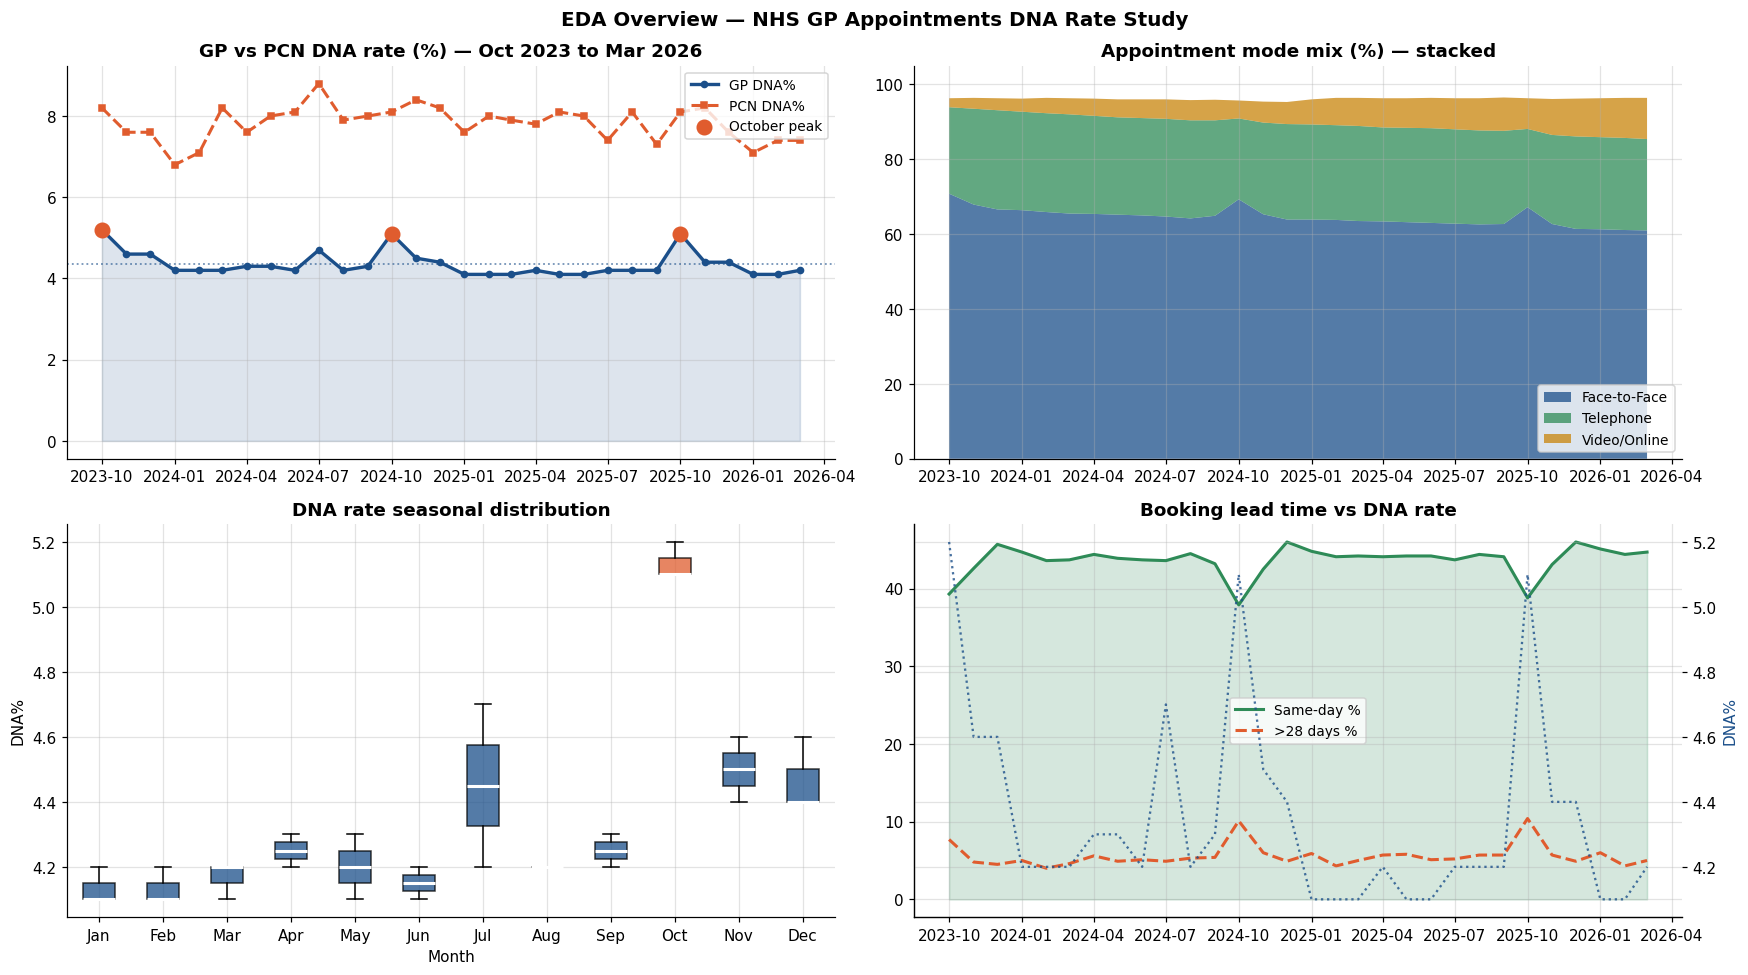

In [5]:
# ─── CELL 4: EDA – Overview ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# DNA time series
axes[0,0].fill_between(df_clean.index, df_clean.dna_pct, alpha=0.15, color=PALETTE["SARIMA"])
axes[0,0].plot(df_clean.index, df_clean.dna_pct, color=PALETTE["SARIMA"], lw=2.2, marker="o", ms=4, label="GP DNA%")
axes[0,0].plot(df_clean.index, df_clean.pcn_dna_pct, color=PALETTE["Prophet"], lw=2, ls="--", marker="s", ms=3.5, label="PCN DNA%")
oct_mask = df_clean.index.month == 10
axes[0,0].scatter(df_clean.index[oct_mask], df_clean.dna_pct[oct_mask], color="#E05C2E", s=90, zorder=6, label="October peak")
axes[0,0].axhline(df_clean.dna_pct.mean(), color=PALETTE["SARIMA"], ls=":", lw=1.2, alpha=0.6)
axes[0,0].set_title("GP vs PCN DNA rate (%) — Oct 2023 to Mar 2026", fontweight="bold")
axes[0,0].legend(fontsize=9)

# Mode mix
axes[0,1].stackplot(df_clean.index,
    df_clean.f2f_pct, df_clean.phone_pct, df_clean.video_pct,
    labels=["Face-to-Face","Telephone","Video/Online"],
    colors=["#1B4F8A","#2E8B57","#C9840A"], alpha=0.75)
axes[0,1].set_title("Appointment mode mix (%) — stacked", fontweight="bold")
axes[0,1].legend(loc="lower right", fontsize=9)
axes[0,1].set_ylim(0, 105)

# Seasonal boxplot
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
groups = [df_clean.dna_pct[df_clean.index.month == m].values for m in range(1,13) if len(df_clean.dna_pct[df_clean.index.month == m]) > 0]
labels_present = [month_names[m-1] for m in range(1,13) if len(df_clean.dna_pct[df_clean.index.month == m]) > 0]
bp = axes[1,0].boxplot(groups, labels=labels_present, patch_artist=True, medianprops=dict(color="white", lw=2))
for patch, lbl in zip(bp["boxes"], labels_present):
    patch.set_facecolor("#E05C2E" if lbl == "Oct" else PALETTE["SARIMA"])
    patch.set_alpha(0.75)
axes[1,0].set_title("DNA rate seasonal distribution", fontweight="bold")
axes[1,0].set_xlabel("Month"); axes[1,0].set_ylabel("DNA%")

# Lead time vs same-day
axes[1,1].fill_between(df_clean.index, df_clean.same_day_pct, alpha=0.2, color=PALETTE["RF"])
axes[1,1].plot(df_clean.index, df_clean.same_day_pct, color=PALETTE["RF"], lw=2, label="Same-day %")
axes[1,1].plot(df_clean.index, df_clean.d28p_pct, color=PALETTE["Prophet"], lw=2, ls="--", label=">28 days %")
ax_r = axes[1,1].twinx()
ax_r.plot(df_clean.index, df_clean.dna_pct, color=PALETTE["SARIMA"], lw=1.5, ls=":", alpha=0.8, label="DNA%")
ax_r.set_ylabel("DNA%", color=PALETTE["SARIMA"])
axes[1,1].set_title("Booking lead time vs DNA rate", fontweight="bold")
axes[1,1].legend(fontsize=9)

plt.suptitle("EDA Overview — NHS GP Appointments DNA Rate Study", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

ADF Statistic: -4.8200
p-value:       0.0000
Result:        Stationary ✓


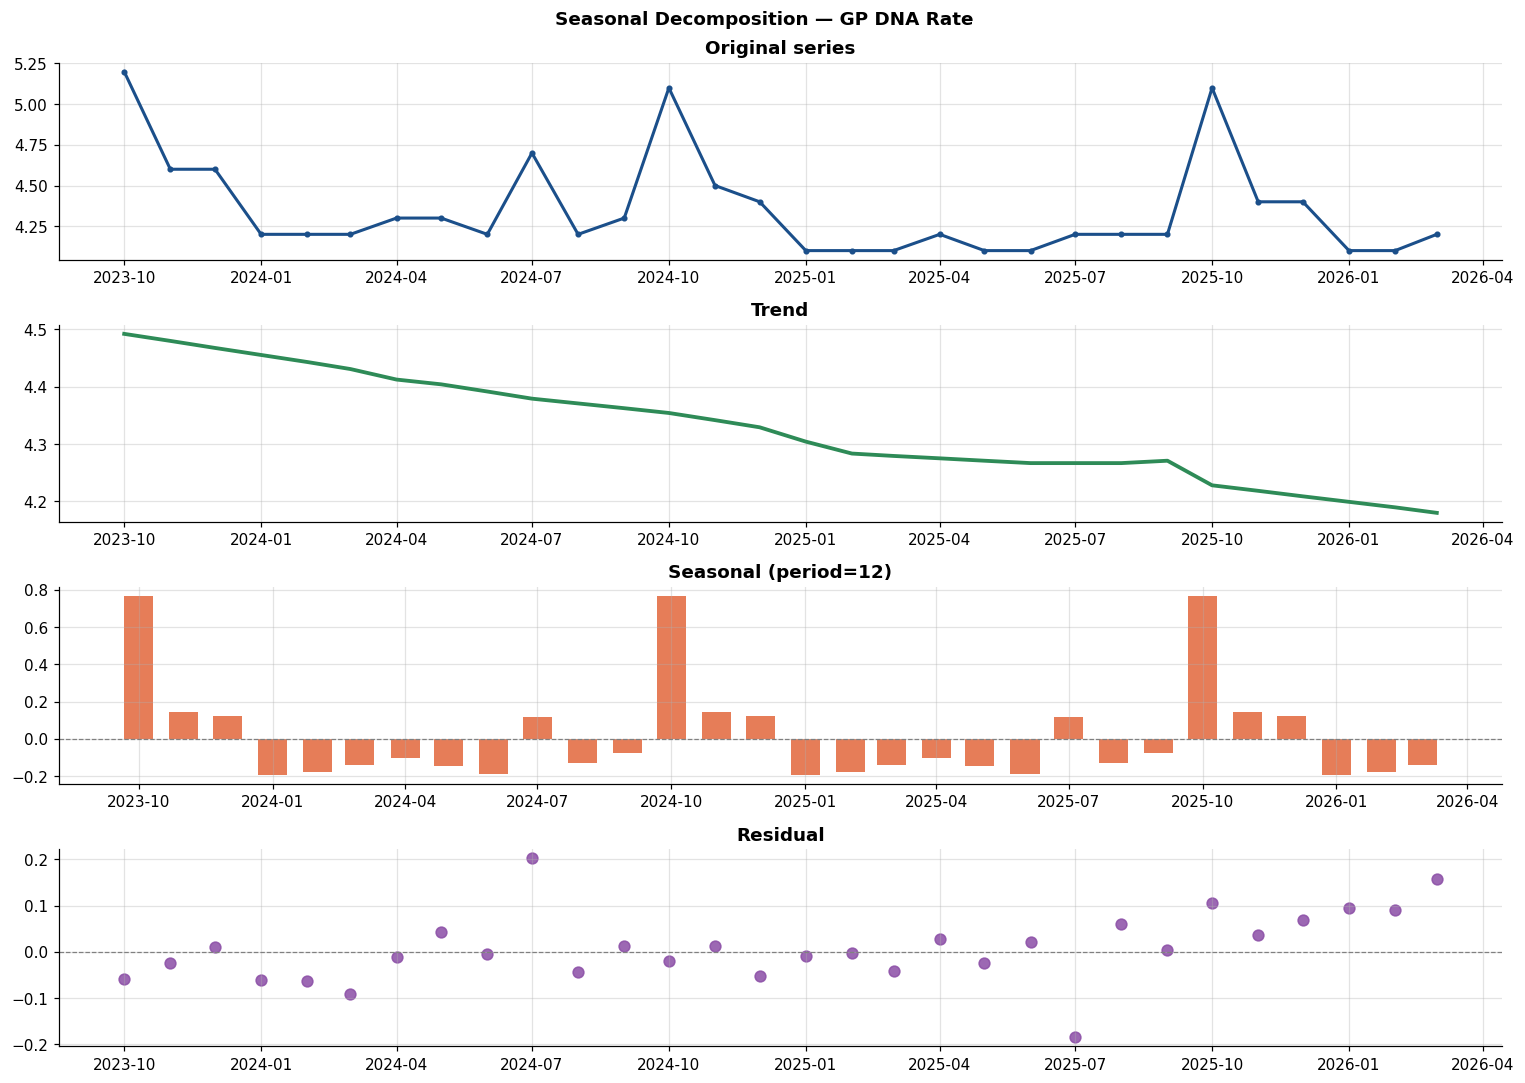

In [6]:
# ─── CELL 5: Time Series Decomposition + Stationarity ──────────────────────
ts = df_clean["dna_pct"]

# ADF test
adf = adfuller(ts)
print(f"ADF Statistic: {adf[0]:.4f}")
print(f"p-value:       {adf[1]:.4f}")
print(f"Result:        {'Stationary ✓' if adf[1] < 0.05 else 'Non-stationary'}")

# Decomposition
decomp = seasonal_decompose(ts, model="additive", period=12, extrapolate_trend="freq")
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(ts.index, ts.values, color=PALETTE["SARIMA"], lw=2, marker="o", ms=3)
axes[0].set_title("Original series", fontweight="bold")
axes[1].plot(ts.index, decomp.trend, color=PALETTE["RF"], lw=2.5)
axes[1].set_title("Trend", fontweight="bold")
axes[2].bar(ts.index, decomp.seasonal, color=PALETTE["Prophet"], alpha=0.8, width=20)
axes[2].axhline(0, color="gray", lw=0.8, ls="--")
axes[2].set_title("Seasonal (period=12)", fontweight="bold")
axes[3].scatter(ts.index, decomp.resid, color=PALETTE["XGBoost"], s=50, alpha=0.85)
axes[3].axhline(0, color="gray", lw=0.8, ls="--")
axes[3].set_title("Residual", fontweight="bold")
plt.suptitle("Seasonal Decomposition — GP DNA Rate", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

## Stage 4 — Feature Engineering

In [7]:
# ─── CELL 6: Feature Engineering ──────────────────────────────────────────
df_feat = df_clean.copy()
df_feat["remote_index"] = df_feat["video_pct"] + df_feat["phone_pct"]

# Lag features
for lag in [1, 2, 3, 6, 12]:
    df_feat[f"dna_lag_{lag}"] = df_feat["dna_pct"].shift(lag)

# Rolling statistics
df_feat["dna_roll3_mean"] = df_feat["dna_pct"].shift(1).rolling(3).mean()
df_feat["dna_roll6_mean"] = df_feat["dna_pct"].shift(1).rolling(6).mean()
df_feat["dna_roll3_std"]  = df_feat["dna_pct"].shift(1).rolling(3).std()
df_feat["dna_ewm3"]       = df_feat["dna_pct"].shift(1).ewm(span=3).mean()

# Temporal encodings
df_feat["month_sin"]   = np.sin(2*np.pi*df_feat.index.month/12)
df_feat["month_cos"]   = np.cos(2*np.pi*df_feat.index.month/12)
df_feat["is_october"]  = (df_feat.index.month == 10).astype(int)

# Trend & momentum features
df_feat["video_mom"]   = df_feat["video_pct"].diff()
df_feat["dna_diff1"]   = df_feat["dna_pct"].diff(1)
df_feat["dna_diff12"]  = df_feat["dna_pct"].diff(12)
df_feat["gp_pcn_gap"]  = df_feat["pcn_dna_pct"] - df_feat["dna_pct"]
df_feat["appts_norm"]  = df_feat["appts_per_day"] / df_feat["appts_per_day"].max()

print(f"Total features after engineering: {df_feat.shape[1]}")
new_feats = [c for c in df_feat.columns if c not in df_clean.columns]
print(f"New features: {new_feats}")
df_feat.tail(5)

Total features after engineering: 31
New features: ['remote_index', 'dna_lag_1', 'dna_lag_2', 'dna_lag_3', 'dna_lag_6', 'dna_lag_12', 'dna_roll3_mean', 'dna_roll6_mean', 'dna_roll3_std', 'dna_ewm3', 'month_sin', 'month_cos', 'is_october', 'video_mom', 'dna_diff1', 'dna_diff12', 'gp_pcn_gap', 'appts_norm']


,working_days,total_appts,dna_pct,attended_pct,f2f_pct,phone_pct,video_pct,same_day_pct,d28p_pct,gp_pct,...,dna_roll3_std,dna_ewm3,month_sin,month_cos,is_october,video_mom,dna_diff1,dna_diff12,gp_pcn_gap,appts_norm
month,,,,,,,,,,,,,,,,,,,,,
2025-11-01,20.0,31140155.0,4.4,89.2,62.7,23.8,9.6,43.1,5.7,43.3,...,0.519615,4.644924,-5.000000e-01,8.660254e-01,0,1.4,-0.7,-0.1,3.8,0.910953
2025-12-01,21.0,30865898.0,4.4,89.4,61.4,24.7,10.1,46.0,4.9,44.3,...,0.472582,4.522462,-2.449294e-16,1.000000e+00,0,0.5,0.0,0.0,3.2,0.859933
2026-01-01,21.0,32748006.0,4.1,89.6,61.3,24.6,10.4,45.1,6.0,44.5,...,0.404145,4.461231,5.000000e-01,8.660254e-01,0,0.3,-0.3,0.0,3.0,0.912369
2026-02-01,20.0,30845608.0,4.1,89.6,61.1,24.6,10.7,44.4,4.3,44.1,...,0.173205,4.280616,8.660254e-01,5.000000e-01,0,0.3,0.0,0.0,3.3,0.902336
2026-03-01,22.0,33908317.0,4.2,89.6,61.0,24.4,11.0,44.7,5.0,44.7,...,0.173205,4.190308,1.000000e+00,6.123234e-17,0,0.3,0.1,0.1,3.2,0.901755


## Stage 5 — Feature Selection

Dataset: 24 samples × 22 features


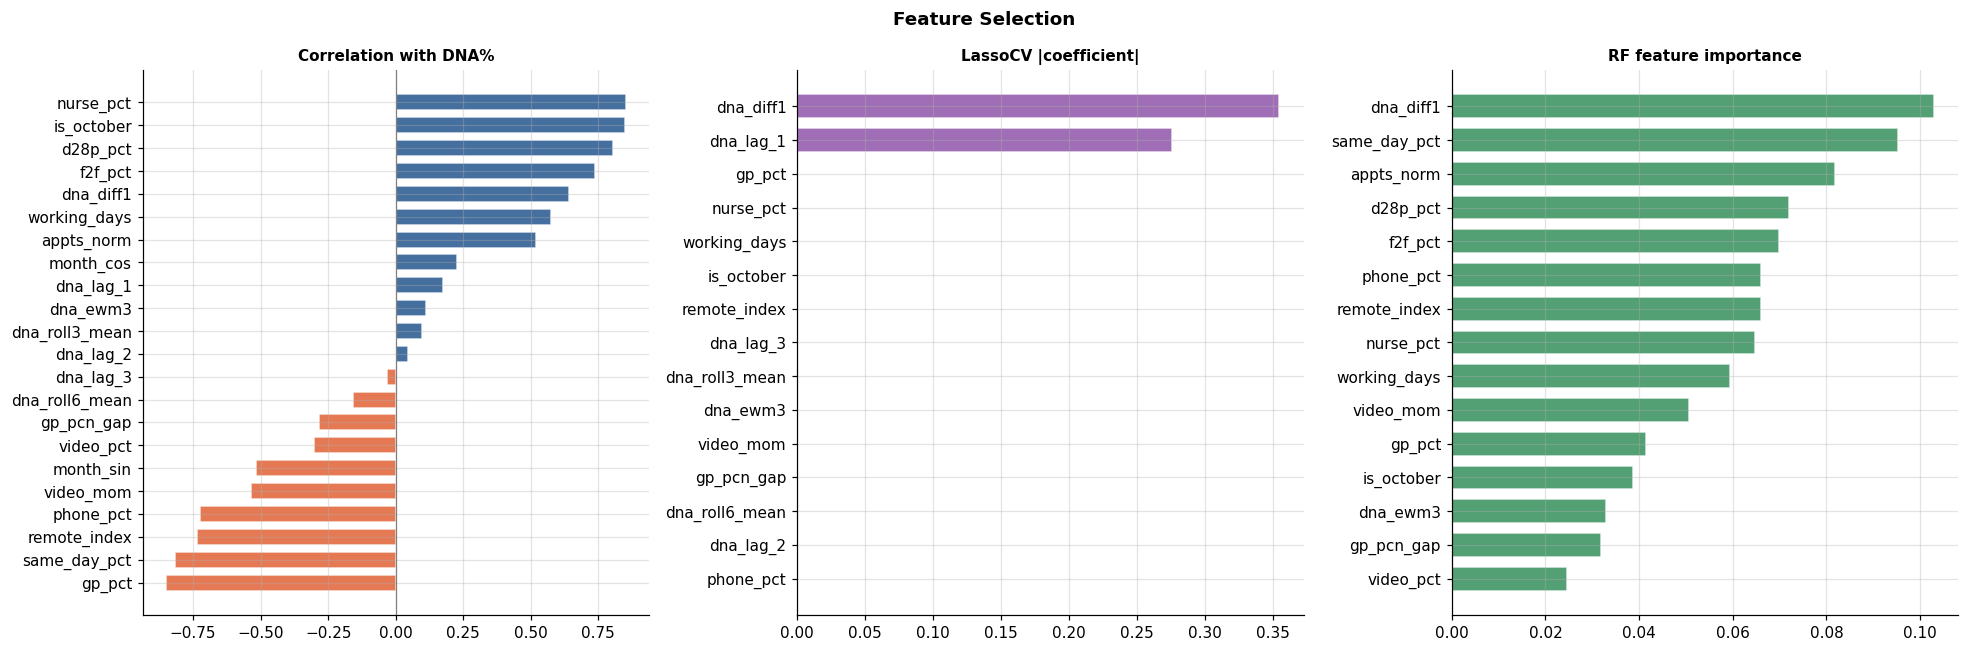

Top-5 Lasso: ['dna_diff1', 'dna_lag_1', 'gp_pct', 'nurse_pct', 'working_days']
Top-5 RF:    ['dna_diff1', 'same_day_pct', 'appts_norm', 'd28p_pct', 'f2f_pct']


In [8]:
# ─── CELL 7: Feature Selection ─────────────────────────────────────────────
FEATURE_COLS = [
    "f2f_pct","video_pct","phone_pct","same_day_pct","d28p_pct",
    "gp_pct","nurse_pct","working_days","remote_index","appts_norm",
    "month_sin","month_cos","is_october","dna_lag_1","dna_lag_2","dna_lag_3",
    "dna_roll3_mean","dna_roll6_mean","dna_ewm3","dna_diff1","video_mom","gp_pcn_gap"
]

df_model = df_feat[FEATURE_COLS + ["dna_pct"]].dropna()
X = df_model[FEATURE_COLS].values
y = df_model["dna_pct"].values
print(f"Dataset: {X.shape[0]} samples × {X.shape[1]} features")

scaler_fs = StandardScaler()
X_sc = scaler_fs.fit_transform(X)

# LassoCV
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_sc, y)
lasso_coefs = pd.Series(np.abs(lasso.coef_), index=FEATURE_COLS).sort_values(ascending=False)

# RF importance
rf_fs = RandomForestRegressor(n_estimators=300, random_state=42, max_features="sqrt")
rf_fs.fit(X_sc, y)
rf_imp = pd.Series(rf_fs.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

# Correlation
corr_target = df_model[FEATURE_COLS + ["dna_pct"]].corr()["dna_pct"].drop("dna_pct").sort_values(key=abs, ascending=False)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, vals, title, color in zip(axes,
    [corr_target.sort_values(), lasso_coefs.sort_values().tail(15), rf_imp.sort_values().tail(15)],
    ["Correlation with DNA%", "LassoCV |coefficient|", "RF feature importance"],
    [PALETTE["SARIMA"], PALETTE["XGBoost"], PALETTE["RF"]]):
    bar_c = [PALETTE["SARIMA"] if v >= 0 else PALETTE["Prophet"] for v in vals.values] if "Correlation" in title else [color]*len(vals)
    ax.barh(vals.index, vals.values, color=bar_c, alpha=0.82, edgecolor="white", height=0.7)
    if "Correlation" in title: ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(title, fontweight="bold", fontsize=10)
plt.suptitle("Feature Selection", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

top5_lasso = lasso_coefs.head(5).index.tolist()
top5_rf    = rf_imp.head(5).index.tolist()
print(f"Top-5 Lasso: {top5_lasso}")
print(f"Top-5 RF:    {top5_rf}")

## Stage 6 — Model Training

In [9]:
# ─── CELL 8: Train/Test Split & ML Feature Matrix ──────────────────────────
ts_full = df_clean["dna_pct"].sort_index()
TRAIN_END = -6
train_ts, test_ts = ts_full.iloc[:TRAIN_END], ts_full.iloc[TRAIN_END:]
print(f"Train: {train_ts.index[0].strftime('%b-%y')} → {train_ts.index[-1].strftime('%b-%y')} ({len(train_ts)} months)")
print(f"Test:  {test_ts.index[0].strftime('%b-%y')} → {test_ts.index[-1].strftime('%b-%y')} ({len(test_ts)} months)")

# Build ML feature matrix with lags
def make_features(series, extra_df, n_lags=3):
    dfm = extra_df.copy()
    for lag in range(1, n_lags+1):
        dfm[f"lag_{lag}"] = series.shift(lag)
    dfm["roll3"]  = series.shift(1).rolling(3).mean()
    dfm["roll6"]  = series.shift(1).rolling(6).mean()
    dfm["ewm3"]   = series.shift(1).ewm(span=3).mean()
    dfm["is_oct"] = (dfm.index.month == 10).astype(int)
    dfm["m_sin"]  = np.sin(2*np.pi*dfm.index.month/12)
    dfm["m_cos"]  = np.cos(2*np.pi*dfm.index.month/12)
    dfm["target"] = series
    return dfm.dropna()

df_clean_copy = df_clean.copy()
df_clean_copy["remote_index"] = df_clean_copy["video_pct"] + df_clean_copy["phone_pct"]
feat_extra = df_clean_copy[["video_pct","f2f_pct","phone_pct","same_day_pct","d28p_pct","working_days","gp_pct","remote_index"]].copy()
df_ml_full = make_features(ts_full, feat_extra)
ML_FEATS = [c for c in df_ml_full.columns if c != "target"]
X_full, y_full = df_ml_full[ML_FEATS].values, df_ml_full["target"].values
split_idx = len(df_ml_full) - 6
X_tr, X_te = X_full[:split_idx], X_full[split_idx:]
y_tr, y_te = y_full[:split_idx], y_full[split_idx:]
scaler_ml = StandardScaler()
X_tr_sc = scaler_ml.fit_transform(X_tr)
X_te_sc = scaler_ml.transform(X_te)
test_index  = df_ml_full.index[split_idx:]
train_index_ml = df_ml_full.index[:split_idx]
print(f"ML feature matrix: {X_full.shape[0]} samples × {X_full.shape[1]} features")

Train: Oct-23 → Sep-25 (24 months)
Test:  Oct-25 → Mar-26 (6 months)
ML feature matrix: 24 samples × 17 features


In [10]:
# ─── CELL 9: SARIMA (1,1,1)(1,1,0,12) ──────────────────────────────────────
sarima_model = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,0,12),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())
sarima_pred_train = sarima_fit.fittedvalues.values
sarima_forecast   = sarima_fit.get_forecast(steps=len(test_ts))
sarima_pred_test  = sarima_forecast.predicted_mean.values
ci = sarima_forecast.conf_int()
sarima_lower, sarima_upper = ci.iloc[:,0].values, ci.iloc[:,1].values
print(f"SARIMA test RMSE: {np.sqrt(mean_squared_error(test_ts.values, sarima_pred_test)):.4f}")

                                      SARIMAX Results                                      
Dep. Variable:                             dna_pct   No. Observations:                   24
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                   0.000
Date:                             Tue, 09 Jun 2026   AIC                              8.000
Time:                                     20:20:21   BIC                                nan
Sample:                                 10-01-2023   HQIC                               nan
                                      - 09-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3384         -0        inf      0.000      -0.338      -0.338
ma.L1         -0.7500      

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [11]:
# ─── CELL 10: Prophet ───────────────────────────────────────────────────────
prophet_train_df = pd.DataFrame({"ds": train_ts.index, "y": train_ts.values})
m_prop = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                 seasonality_mode="additive", changepoint_prior_scale=0.3,
                 seasonality_prior_scale=5.0, interval_width=0.90)
m_prop.add_seasonality(name="quarterly", period=91.25, fourier_order=3)
m_prop.fit(prophet_train_df)
future_test = pd.DataFrame({"ds": test_ts.index})
prophet_forecast = m_prop.predict(future_test)
prophet_pred_test  = prophet_forecast["yhat"].values
prophet_lower      = prophet_forecast["yhat_lower"].values
prophet_upper      = prophet_forecast["yhat_upper"].values
future_all_train   = pd.DataFrame({"ds": train_ts.index})
prophet_pred_train = m_prop.predict(future_all_train)["yhat"].values
print(f"Prophet test RMSE: {np.sqrt(mean_squared_error(test_ts.values, prophet_pred_test)):.4f}")

INFO:prophet:n_changepoints greater than number of observations. Using 18.


Prophet test RMSE: 0.5367


In [12]:
# ─── CELL 11: Random Forest ─────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=2,
                                  max_features=0.6, random_state=42, n_jobs=-1)
rf_model.fit(X_tr_sc, y_tr)
rf_pred_test  = rf_model.predict(X_te_sc)
rf_pred_train = rf_model.predict(X_tr_sc)

# Bootstrap 90% CI
rng = np.random.default_rng(42)
n_boot = 200
boot_preds = []
for _ in range(n_boot):
    idx = rng.integers(0, len(X_tr_sc), len(X_tr_sc))
    rb = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0, max_features=0.6)
    rb.fit(X_tr_sc[idx], y_tr[idx])
    boot_preds.append(rb.predict(X_te_sc))
boot_arr = np.array(boot_preds)
rf_lower = np.percentile(boot_arr, 5, axis=0)
rf_upper = np.percentile(boot_arr, 95, axis=0)
print(f"RF test RMSE: {np.sqrt(mean_squared_error(y_te, rf_pred_test)):.4f}")

# ─── XGBoost ─────────────────────────────────────────────────────────────────
xgb_model = XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.04,
                          subsample=0.8, colsample_bytree=0.7, reg_alpha=0.1,
                          reg_lambda=1.5, random_state=42, verbosity=0)
xgb_model.fit(X_tr_sc, y_tr, eval_set=[(X_te_sc, y_te)], verbose=False)
xgb_pred_test  = xgb_model.predict(X_te_sc)
xgb_pred_train = xgb_model.predict(X_tr_sc)
boot_xgb = []
for _ in range(n_boot):
    idx = rng.integers(0, len(X_tr_sc), len(X_tr_sc))
    xb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=0, verbosity=0)
    xb.fit(X_tr_sc[idx], y_tr[idx])
    boot_xgb.append(xb.predict(X_te_sc))
xgb_lower = np.percentile(np.array(boot_xgb), 5, axis=0)
xgb_upper = np.percentile(np.array(boot_xgb), 95, axis=0)
print(f"XGBoost test RMSE: {np.sqrt(mean_squared_error(y_te, xgb_pred_test)):.4f}")

# ─── MLP ─────────────────────────────────────────────────────────────────────
mlp_model = MLPRegressor(hidden_layer_sizes=(64,32,16), activation="relu", solver="adam",
                          alpha=0.01, learning_rate_init=0.005, max_iter=2000,
                          early_stopping=True, validation_fraction=0.15,
                          random_state=42, tol=1e-5)
mlp_model.fit(X_tr_sc, y_tr)
mlp_pred_test  = mlp_model.predict(X_te_sc)
mlp_pred_train = mlp_model.predict(X_tr_sc)
boot_mlp = []
for _ in range(n_boot):
    idx = rng.integers(0, len(X_tr_sc), len(X_tr_sc))
    mb = MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=0, tol=1e-4)
    mb.fit(X_tr_sc[idx], y_tr[idx])
    boot_mlp.append(mb.predict(X_te_sc))
mlp_lower = np.percentile(np.array(boot_mlp), 5, axis=0)
mlp_upper = np.percentile(np.array(boot_mlp), 95, axis=0)
print(f"MLP test RMSE: {np.sqrt(mean_squared_error(y_te, mlp_pred_test)):.4f}")

RF test RMSE: 0.2212
XGBoost test RMSE: 0.2168
MLP test RMSE: 1.6072


## Stage 7 — Evaluation

In [13]:
# ─── CELL 12: Evaluation Metrics ───────────────────────────────────────────
results = {
    "SARIMA":  {"test": sarima_pred_test,  "train": sarima_pred_train,  "lower": sarima_lower, "upper": sarima_upper},
    "Prophet": {"test": prophet_pred_test, "train": prophet_pred_train, "lower": prophet_lower, "upper": prophet_upper},
    "RF":      {"test": rf_pred_test,      "train": rf_pred_train,      "lower": rf_lower,     "upper": rf_upper},
    "XGBoost": {"test": xgb_pred_test,    "train": xgb_pred_train,     "lower": xgb_lower,    "upper": xgb_upper},
    "MLP":     {"test": mlp_pred_test,     "train": mlp_pred_train,     "lower": mlp_lower,    "upper": mlp_upper},
}
test_actuals = {"SARIMA": test_ts.values, "Prophet": test_ts.values,
                "RF": y_te, "XGBoost": y_te, "MLP": y_te}
train_actuals = {"SARIMA": train_ts.values, "Prophet": train_ts.values,
                 "RF": y_tr, "XGBoost": y_tr, "MLP": y_tr}

def mape(y_true, y_pred):
    return 100 * np.mean(np.abs((np.array(y_true)-np.array(y_pred))/np.array(y_true)))

rows = {}
for m, res in results.items():
    yt, yp = test_actuals[m], res["test"]
    ytr, ytrp = train_actuals[m], res["train"]
    rows[m] = {
        "RMSE":       round(np.sqrt(mean_squared_error(yt, yp)), 4),
        "MAE":        round(mean_absolute_error(yt, yp), 4),
        "MAPE%":      round(mape(yt, yp), 3),
        "R²":         round(r2_score(yt, yp), 4),
        "Train RMSE": round(np.sqrt(mean_squared_error(ytr, ytrp)), 4),
    }

metrics_df = pd.DataFrame(rows).T.sort_values("RMSE")
print("\n=== EVALUATION RESULTS ===")
display(metrics_df)

# Time-series CV
tscv = TimeSeriesSplit(n_splits=5, test_size=2)
for name, mdl in [("RF", rf_model), ("XGBoost", xgb_model), ("MLP", mlp_model)]:
    fold_rmses = []
    for tr_idx, te_idx in tscv.split(X_full):
        sc = StandardScaler()
        xtr = sc.fit_transform(X_full[tr_idx]); xte = sc.transform(X_full[te_idx])
        mdl.fit(xtr, y_full[tr_idx])
        fold_rmses.append(np.sqrt(mean_squared_error(y_full[te_idx], mdl.predict(xte))))
    print(f"CV RMSE {name}: {np.mean(fold_rmses):.4f} ± {np.std(fold_rmses):.4f}")


=== EVALUATION RESULTS ===


,RMSE,MAE,MAPE%,R²,Train RMSE
SARIMA,0.1660,0.1548,3.560,0.7666,1.2087
XGBoost,0.2168,0.1687,3.707,0.6019,0.0279
RF,0.2212,0.1582,3.412,0.5854,0.1249
Prophet,0.5367,0.4909,11.535,-1.4395,0.0000
MLP,1.6072,1.4297,33.459,-20.8814,1.2428


CV RMSE RF: 0.1476 ± 0.1132
CV RMSE XGBoost: 0.1515 ± 0.0985
CV RMSE MLP: 1.3637 ± 0.7500


## Stage 8 — Result Visualisations

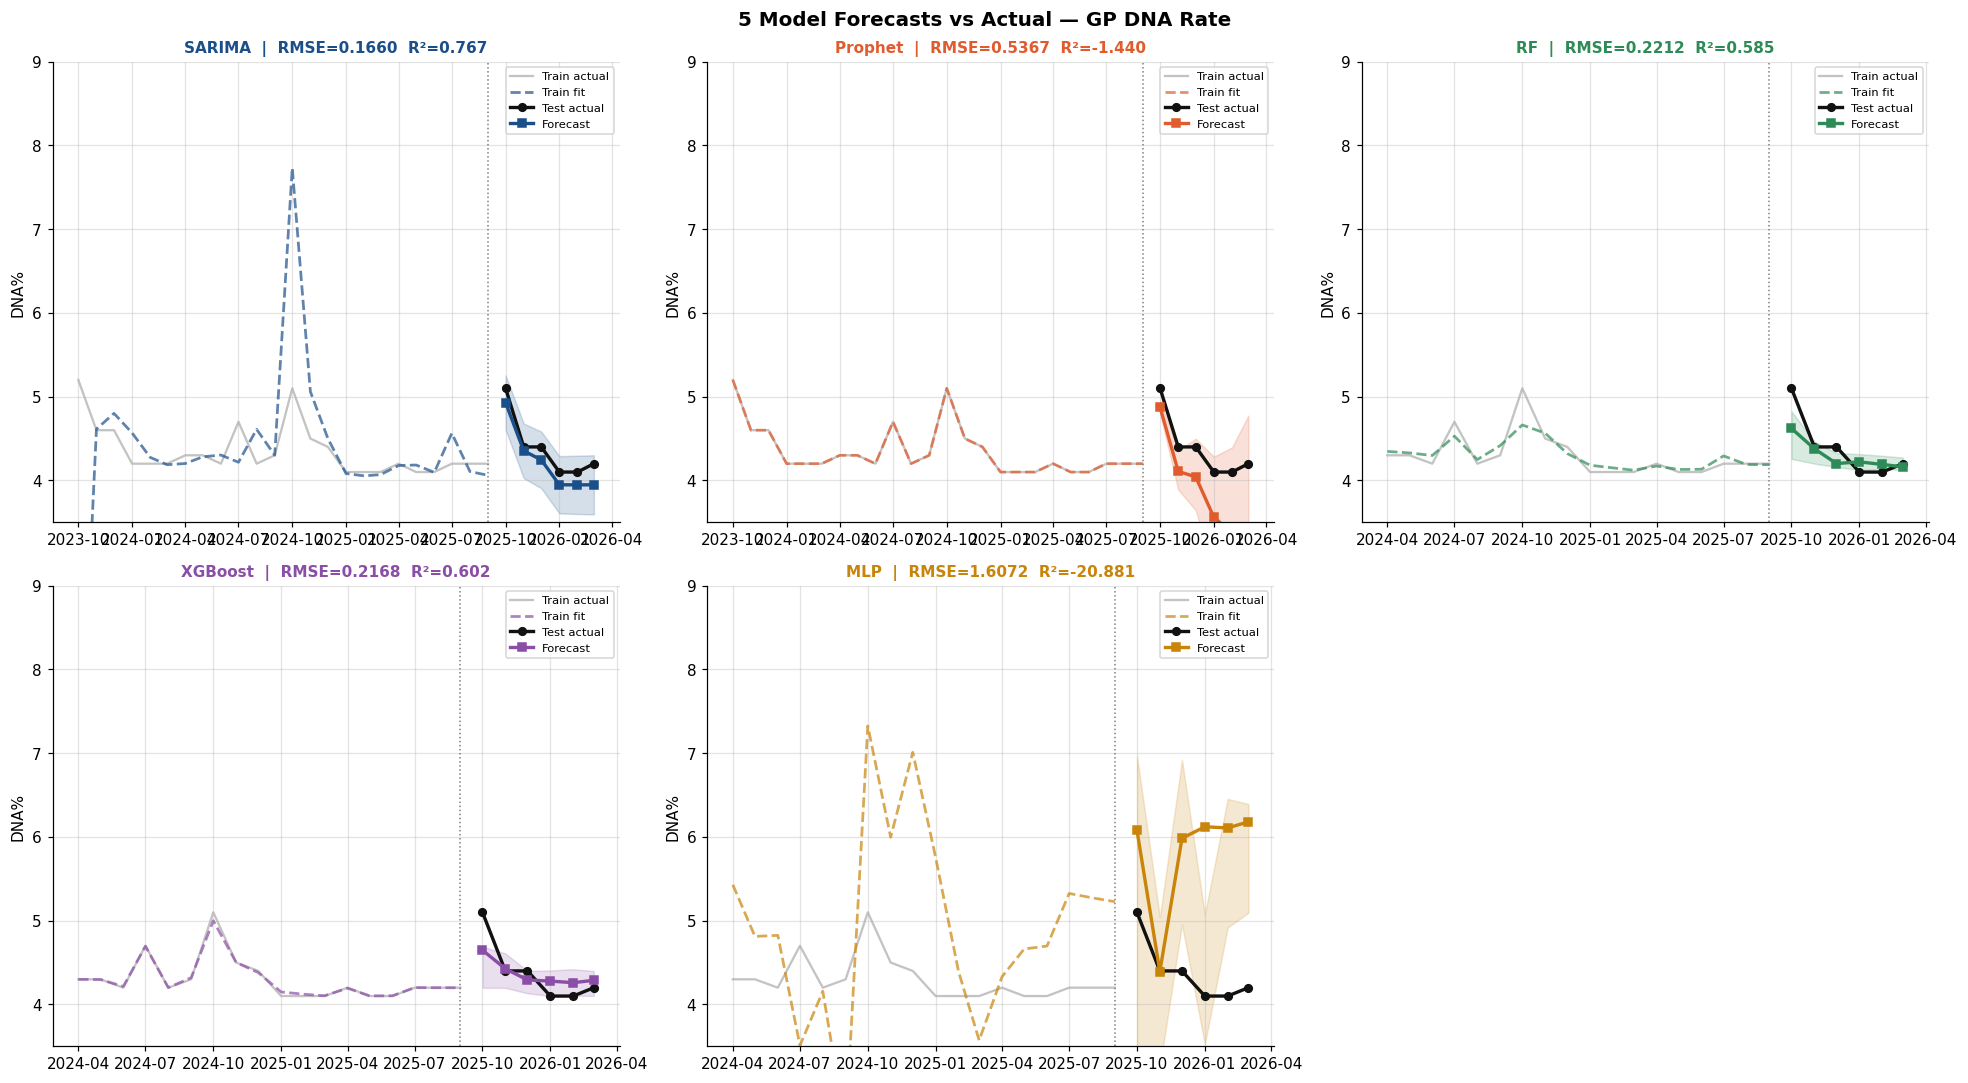

In [14]:
# ─── CELL 13: All Models — Forecast vs Actual ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

test_dates = {"SARIMA": test_ts.index, "Prophet": test_ts.index,
              "RF": test_index, "XGBoost": test_index, "MLP": test_index}
train_dates = {"SARIMA": train_ts.index, "Prophet": train_ts.index,
               "RF": train_index_ml, "XGBoost": train_index_ml, "MLP": train_index_ml}

for i, (mname, color) in enumerate(zip(["SARIMA","Prophet","RF","XGBoost","MLP"], MODEL_COLORS)):
    ax = axes[i]
    ax.plot(train_dates[mname], train_actuals[mname], color="#aaa", lw=1.5, alpha=0.7, label="Train actual")
    ax.plot(train_dates[mname], results[mname]["train"], color=color, lw=1.8, ls="--", alpha=0.7, label="Train fit")
    ax.plot(test_dates[mname], test_actuals[mname], color="#111", lw=2.2, marker="o", ms=5, label="Test actual")
    ax.plot(test_dates[mname], results[mname]["test"], color=color, lw=2.2, marker="s", ms=5, label="Forecast")
    ax.fill_between(test_dates[mname], results[mname]["lower"], results[mname]["upper"], color=color, alpha=0.18)
    ax.axvline(train_dates[mname][-1], color="gray", lw=1, ls=":")
    r, m_v = rows[mname]["R²"], rows[mname]["RMSE"]
    ax.set_title(f"{mname}  |  RMSE={m_v:.4f}  R²={r:.3f}", fontweight="bold", fontsize=10, color=color)
    ax.set_ylabel("DNA%"); ax.legend(fontsize=7.5)
    ax.set_ylim(3.5, 9)
axes[5].axis("off")
plt.suptitle("5 Model Forecasts vs Actual — GP DNA Rate", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

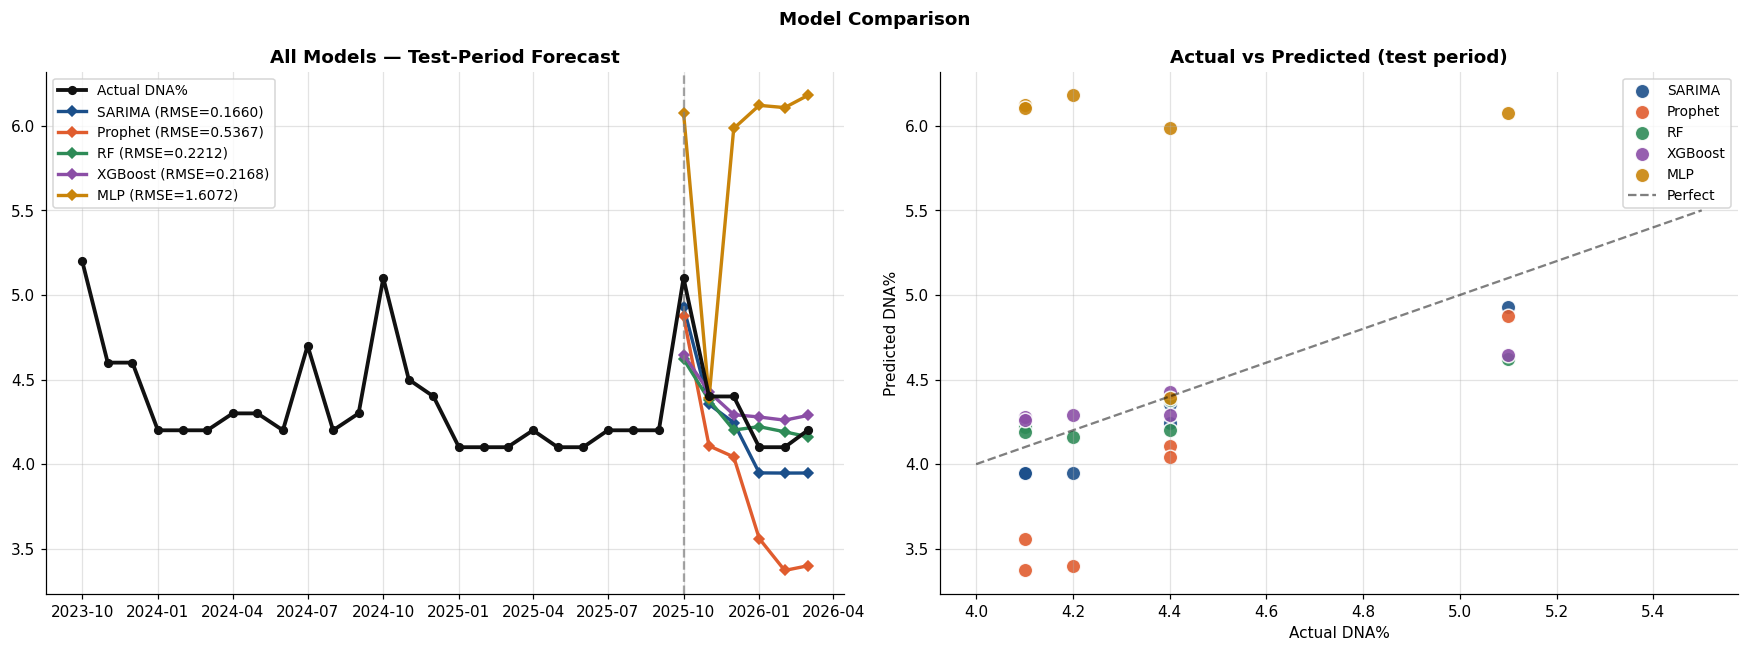

In [15]:
# ─── CELL 14: Head-to-Head Comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All forecasts on test period
axes[0].plot(ts_full.index, ts_full.values, color="#111", lw=2.5, marker="o", ms=5, label="Actual DNA%", zorder=10)
for mname, color in zip(["SARIMA","Prophet","RF","XGBoost","MLP"], MODEL_COLORS):
    axes[0].plot(test_dates[mname], results[mname]["test"], color=color, lw=2.2, marker="D", ms=5,
                 label=f"{mname} (RMSE={rows[mname]['RMSE']:.4f})")
axes[0].axvline(test_ts.index[0], color="gray", lw=1.5, ls="--", alpha=0.7)
axes[0].set_title("All Models — Test-Period Forecast", fontweight="bold"); axes[0].legend(fontsize=9)

# Actual vs predicted scatter
for mname, color in zip(["SARIMA","Prophet","RF","XGBoost","MLP"], MODEL_COLORS):
    axes[1].scatter(test_actuals[mname], results[mname]["test"], color=color, s=90, alpha=0.9,
                    edgecolors="white", label=mname)
mn, mx = 4.0, 5.5
axes[1].plot([mn, mx], [mn, mx], "k--", lw=1.5, alpha=0.5, label="Perfect")
axes[1].set_xlabel("Actual DNA%"); axes[1].set_ylabel("Predicted DNA%")
axes[1].set_title("Actual vs Predicted (test period)", fontweight="bold"); axes[1].legend(fontsize=9)

plt.suptitle("Model Comparison", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

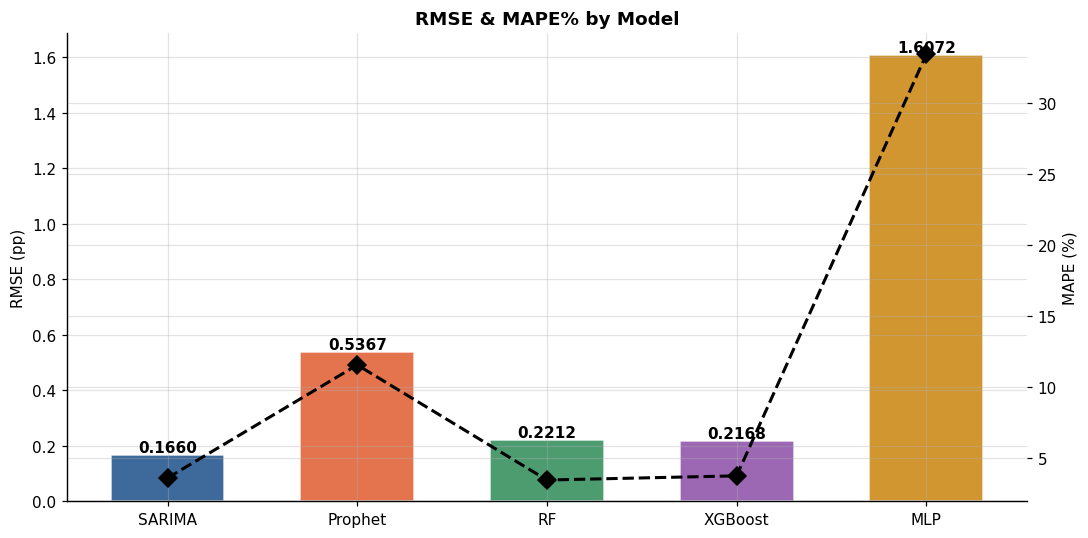


Final Rankings (sorted by RMSE):


,RMSE,MAE,MAPE%,R²,Train RMSE
SARIMA,0.1660,0.1548,3.560,0.7666,1.2087
XGBoost,0.2168,0.1687,3.707,0.6019,0.0279
RF,0.2212,0.1582,3.412,0.5854,0.1249
Prophet,0.5367,0.4909,11.535,-1.4395,0.0000
MLP,1.6072,1.4297,33.459,-20.8814,1.2428


In [16]:
# ─── CELL 15: Metrics Summary ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(5)
model_ord = ["SARIMA","Prophet","RF","XGBoost","MLP"]
rmse_vals = [rows[m]["RMSE"] for m in model_ord]
bars = ax.bar(x_pos, rmse_vals, color=MODEL_COLORS, alpha=0.85, edgecolor="white", width=0.6)
ax2 = ax.twinx()
ax2.plot(x_pos, [rows[m]["MAPE%"] for m in model_ord], "kD--", ms=8, lw=2, label="MAPE%")
ax2.set_ylabel("MAPE (%)")
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x_pos); ax.set_xticklabels(model_ord)
ax.set_ylabel("RMSE (pp)"); ax.set_title("RMSE & MAPE% by Model", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()
print("\nFinal Rankings (sorted by RMSE):")
display(metrics_df)